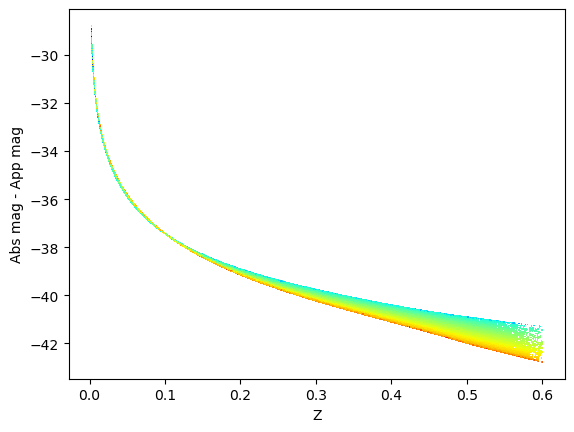

South sample size: 252535
North sample size: 114176
<Table length=366711>
       name           mean        std         min         max    
----------------- ----------- ----------- ----------- -----------
         TARGETID 5.26279e+06 3.00334e+06          40 1.04801e+07
           TILEID     23073.8     1826.76       20000       27852
  ABSMAG_RP1_ORIG    -20.2155      1.2019    -23.3813    -11.0967
REST_GMR_0P1_ORIG    0.723118    0.235564   -0.419652      1.6855
          gmr_obs    0.980094    0.391509   -0.390772     2.43061
              DEC     22.2346     23.1953    -19.2341     79.0423
               RA     184.712     92.1401 0.000157519         360
                Z    0.205787    0.097801  0.00234379     0.59973
            NTILE     2.41685    0.917926           1           5
              reg          --          --          --          --
 FRAC_TLOBS_TILES    0.985274   0.0265102         0.6           1
           WEIGHT     1.21142    0.662542           1          36
  

In [14]:
import catalogue_analysis as ca
import redshift_weights as rw
import kcorrections as k
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from kcorrections  import DESI_KCorrection #Needed to access the model k-corections
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units  #Dangerous as needs to be consistent with call in catalogue_analysis.py
import matplotlib.pyplot as plt

fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections

# Specify regions to loop over
regions=('S','N')
fresh_kcorr = False  # whether to recompute k-correction

catalogue='/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/altmtl0/loa-v1/mock0/LSScats/BGS_BRIGHT_clustering.dat.fits'
datall=Table.read(catalogue)

#Sanity check that apparent and absolute magnitudes are related.
plt.scatter(datall['Z'],datall['R_MAG_ABS']-datall['R_MAG_APP'],marker=',',lw=0,s=1.0,c=datall['G_R_REST'],cmap='jet')
plt.xlabel('Z')
plt.ylabel('Abs mag - App mag')
plt.show()

datall.rename_column('PHOTSYS', 'reg')
datall.rename_column('R_MAG_APP', 'rmag')
datall.rename_column('R_MAG_ABS','ABSMAG_RP1_ORIG')
datall.rename_column('G_R_OBS','gmr_obs') 
datall.rename_column('G_R_REST','REST_GMR_0P1_ORIG') 



#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
dat=datall[smask]    
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())





#Placeholders for quantities to be estimated from the observed quantities
dat.add_column(Column(name='ABSMAG_RP1', data=np.zeros(dat["Z"].size)))
dat.add_column(Column(name='REST_GMR_0P1', data=np.zeros(dat["Z"].size)))

dat.info('stats')

for reg in regions:
    mask=(dat['reg']==reg)
    print('stats for', reg)
    temp=dat[mask]
    temp.info('stats')


In [5]:

catalogue="/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CubicBox/BGS/v1/z0.200/AbacusSummit_base_c000_ph000_N.fits"
cube=Table.read(catalogue)
cube.info('stats')



<Table length=220424052>
   name      mean        std        min        max    
--------- ---------- ----------- --------- -----------
R_MAG_ABS    -19.324     0.91782   -23.511         -18
 G_R_REST   0.661437    0.241683 -0.405386     1.63034
HALO_MASS    1928.01     7693.57    13.709      295815
      cen   0.642649    0.479219         0           1
        x  -0.131045       577.2     -1000        1000
        y   0.270663     577.633     -1000        1000
        z   -1.03464     576.688     -1000        1000
       vx -0.0443221     397.095  -5904.76     5913.52
       vy -0.0549591     396.333  -6090.75     6754.78
       vz -0.0232084     400.762  -6486.26     5787.02
 FILE_NUM    16.5076     9.81332         0          33
  HALO_ID 8.4997e+16 4.90908e+16   2.5e+07 1.70017e+17


/tmp/ipykernel_1108597/3204899140.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(bin_cen,np.log10(phi), label='LF of cube')


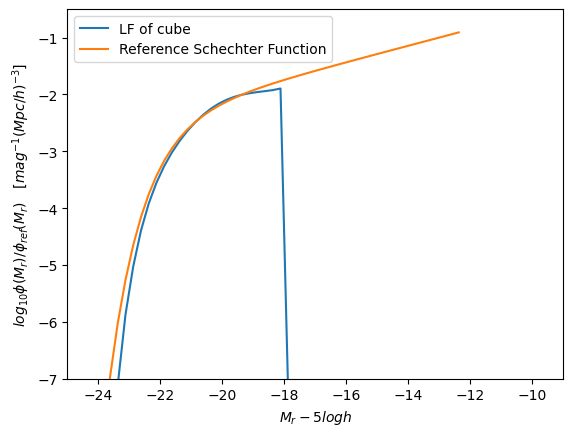

In [13]:
# Reference Schehcter function from Sam's draft paper Table 1
bins = np.arange(-24.0, -12.1, 0.25)
bin_cen = (bins[:-1] + bins[1:]) / 2.0


phi,binr=np.histogram(cube['R_MAG_ABS'], bins=bins)
phi=phi/(8.0e+09*0.25)
plt.plot(bin_cen,np.log10(phi), label='LF of cube')

phi_star=10.0**(-2.13)
alpha=-1.36
mstar=-21.10
l_lstar= 10.0**(0.4*(-bin_cen+mstar))
phi_sch= phi_star * l_lstar**(1.0+alpha) * np.exp(-l_lstar) *(np.log(10.0)/2.5)
log_phi_sch = np.log10(phi_sch)
plt.plot(bin_cen,log_phi_sch, label='Reference Schechter Function')
plt.xlabel('$M_r - 5 log h$')
plt.ylabel('$log_{10} \phi(M_r)/\phi_{ref}(M_r) \quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-25,-9])
plt.ylim([-7.0,-0.5])
plt.legend()
plt.show()
        

In [ ]:
catalogue="/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CutSky/BGS/v0.1/z0.200/cutsky_BGS_z0.200_AbacusSummit_base_c000_ph000.fits"
datall=Table.read(catalogue)
#datall.rename_column('PHOTSYS', 'reg')
datall.rename_column('R_MAG_APP', 'rmag')
datall.rename_column('R_MAG_ABS','ABSMAG_RP1_ORIG')
datall.rename_column('G_R_OBS','gmr_obs') 
datall.rename_column('G_R_REST','REST_GMR_0P1_ORIG') 
datall.info('stats')




In [ ]:
igal=dat['TARGETID'][0]
print('igal=',dat['TARGETID'][0])
print('Fibre Assigned mock:')
print(dat[0])
print('Full Sky mock:')
print(datall[igal])

In [15]:
catalogue="/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/forFA0.fits"
forFAO=Table.read(catalogue)
#
forFAO.info('stats')


<Table length=17782346>
     name         mean        std         min         max    
------------- ----------- ----------- ----------- -----------
    R_MAG_APP     19.1507    0.888814      8.3046      20.175
    R_MAG_ABS    -20.1008     1.21224    -25.2496    -10.1176
     G_R_REST    0.696392    0.243327   -0.878814     1.80514
      G_R_OBS     1.01395    0.402674    -0.85201      2.4847
          DEC     22.6394     23.3098    -19.3392     79.2803
           RA     182.934     94.3578 3.81136e-05         360
        TRUEZ    0.240846    0.112418  0.00129866     0.80067
         RSDZ    0.240967    0.112311  0.00110612    0.799863
        IN_Y5           1           0           1           1
  DESI_TARGET 1.15292e+18           0 1.15292e+18 1.15292e+18
PRIORITY_INIT     2066.61     47.1621        2000        2100
     PRIORITY     2066.61     47.1621        2000        2100
  NUMOBS_MORE           2           0           2           2
  NUMOBS_INIT           2           0         

In [ ]:
igal=dat['TARGETID'][0]
print('igal=',dat['TARGETID'][0])
print('Fibre Assigned mock:')
print(dat[0])
mask=(forFAO['TARGETID']==igal)
print('For FA mock:')
print(forFAO[mask])
print(forFAO['DESI_TARGET'][mask])

In [ ]:
# If you want to recompute the colour lookup table and k-correction polynomials set fresh=True otherwise re-use stored table and fits
fresh = fresh_kcorr
plot= True
info= True
forceN = True  # Force use of N lookup and k-correction for all data

if (fresh == True) :
  print('Recomputing colour look-up and k-correction polynomials')
  # Read John Moustakas's Fast Spec Catalogue
  fsf=ca.read_fsf(fsffile)
  print('statistics of the Fast Spectral Fitting Catalogue used for k-correction')
  fsf.info('stats')
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=fresh,plot=plot,forceN=forceN)  
else:
  fsf='null' #just defining the variable so code doesn't complain  
  print('Using pre-computed colour look-up and k-correction polynomials')
  #compute rest frame colours and absolute magnitudes using k-corrections already computed from the fsf catalogue
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=False,plot=plot,forceN=forceN)

if (info):
   print('Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:')
   dat.info('stats')

In [ ]:
for reg in regions:
    mask=(dat["reg"]==reg)

    plt.scatter(dat['REST_GMR_0P1'][mask],dat['REST_GMR_0P1_ORIG'][mask],marker=',',lw=0,s=1.0,c=dat['REST_GMR_0P1'][mask],cmap='jet')
    plt.xlabel('Rest Fame G-R from look-up table and k-correction')
    plt.ylabel('original Rest Fram G-R')
    plt.show()

    plt.scatter(dat['ABSMAG_RP1'][mask],dat['ABSMAG_RP1_ORIG'][mask],marker=',',lw=0,s=1.0,c=dat['REST_GMR_0P1'][mask],cmap='jet')
    plt.xlabel('Absolute Magnitude From look-up table and k-correction')
    plt.ylabel('original Absolute Magnitude')
    plt.show()
    


In [ ]:

#sky plot
ca.sky_plot(dat,regions)


In [ ]:
#colour-magnitude distributions
ca.plot_col_mag(dat,regions)


In [ ]:
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dndz,binz=np.histogram(dat['Z'][regmask], bins=100,  weights=weights[regmask])
        bin_cen=(binz[1:]+binz[:-1])/2.0
        dz=binz[1]-binz[0] #redshift bin width
        dndz= (dndz/dz)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,dndz,color=Sel['col'],alpha=0.5,label=reg)    
plt.ylabel('$dN_{sq deg}/dz$')        
plt.xlabel('$z$')        
plt.xlim(0.0,0.6) 
plt.ylim(0.0,3600.0)
plt.legend()
plt.show()        


In [ ]:
#Plot number counts
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram(dat['rmag'][regmask], bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dm=bin[1]-bin[0] #bin width
        dndm= (dn/dm)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,np.log10(dndm+1.0e-20),color=Sel['col'],alpha=0.5,label=reg)
plt.ylabel('$log dN_{sq deg}/dr$')        
plt.xlabel('$r$')        
plt.xlim(11,20) 
plt.ylim(-1.5,3.0)
plt.legend()
plt.show()    

In [ ]:
#plot oberver frame g-r colour distribution in redshift bins
for slice in (1,2,3):
    if (slice==1): 
        zmin=0
        zmax=0.15
        ltype='dotted'
    if (slice==2): 
        zmin=0.15
        zmax=0.25
        ltype='dashed'
    if (slice==3): 
        zmin=0.25
        zmax=0.5
        ltype='solid'
    for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg) & (dat['gmr_obs']>0.0) & (dat['gmr_obs']<2.5)  & (dat['Z']>zmin) & (dat['Z']<zmax)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram((dat['gmr_obs'][regmask]), bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dcol=bin[1]-bin[0] #bin width
        dndcol= (dn/dcol)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,(dndcol),color=Sel['col'],alpha=0.5,label=reg+str(slice),linestyle=ltype)
plt.ylabel('$log\ dN_{sq deg}/d(g-r)$')        
plt.xlabel('$g-r$')        
plt.xlim(0.0,2.5) 
plt.ylim(0,400)
plt.legend()
plt.show()

In [ ]:
# Compute zmax and vmax values
ca.compute_zmax_vmax(dat,regions,forceN=True)
#  

if plot:    
    # Make some test plots but avoid plotting data from any unprocessed region
    if (len(regions) > 1):
       regmask=  ((dat['reg']=='N') | (dat['reg']=='S'))
    else:    
       regmask= (dat['reg']==regions)
    #Plots of how zmax depends on absolute magnitude, colour and redshift
    ca.plot_zmax_absmag(dat[regmask])
    ca.plot_zmax_z(dat[regmask])
    #Plots of how zmin depends on absolute magnitude, colour and redshift
    ca.plot_zmin_absmag(dat)
    ca.plot_zmin_z(dat[regmask])

In [ ]:
# Write the Augmented table to a fits file 
# Add meta data to store the selection cuts used in defining this sample and other information
Sel=ca.selection('N')
dat.meta['Qevol_N']=Sel['Qevol']
dat.meta['zmax_N']=Sel['zmax']
dat.meta['zmin_N']=Sel['zmin']
dat.meta['bright_N']=Sel['bright']
dat.meta['faint_N']=Sel['faint']
dat.meta['area_N']=Sel['area']
dat.meta['f_ran_N']=Sel['f_ran']
dat.meta['col_N']=Sel['col']
dat.meta['style_N']=Sel['style']

Sel=ca.selection('S')
dat.meta['Qevol_S']=Sel['Qevol']
dat.meta['zmax_S']=Sel['zmax']
dat.meta['zmin_S']=Sel['zmin']
dat.meta['bright_S']=Sel['bright']
dat.meta['faint_S']=Sel['faint']
dat.meta['area_S']=Sel['area']
dat.meta['f_ran_S']=Sel['f_ran']
dat.meta['col_S']=Sel['col']
dat.meta['style_S']=Sel['style']
#
# Store the parameters of the cosmology used to make this catalogue
dat.meta['H0']=ca.cosmo.H0.value
dat.meta['Tcmb0']=ca.cosmo.Tcmb0.value
dat.meta['Om0']=ca.cosmo.Om0
#

# Write the table complete with its meta data
#
dat.write('sdata/BGS_mockY3_Oct2025.fits',overwrite=True) 
